# **TAS (Tele Assistance System) Analytical Modelling**
NOTE: _[DASA CASE STUDY 1]_

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Analytically Solve the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for Software Architecture (DASA) methodology, its software tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

## **Project Overview**

TAS (Tele Assistance System) is a software solution for remote monitoring and telehealth services in chronic ill patients (e.g.: diabetes).

As seen in the [Context Diagram](#Context-Diagram) shows how patients with chronic conditions (such as diabetes) interact with the system using wearable monitoring devices that collect vital signs. These measurements are transmitted to TAS, which processes and analyzes the data using third-party Medical Analysis Services (MAS). Based on analysis results, TAS can trigger appropriate responses - either sending medication adjustments via Drug Services (DS) for non-critical situations or dispatching emergency assistance through Alarm Services (AS) when critical conditions are detected.


The TAS (Tele Assistance System) context diagram illustrates how the system operates within its broader healthcare ecosystem. At the center is the TAS core, which connects patients at home to various healthcare services through a self-adaptive architecture. 


The diagram notes highlights the system's self-adaptive capabilities through the MAPE-K (Monitor-Analyze-Plan-Execute plus Knowledge) feedback loop, which continuously evaluates service quality and performance. This allows TAS to dynamically reconfigure itself by switching between alternative service providers when failures or delays occur, ensuring reliable telehealth support even in uncertain conditions.

The diagram notes highlights the system's main quality concerns:
1. Improving service reliability
2. Enhancing response time
3. Reducing costs

This concerns translates to five possible adaptation scenarios:
1. Replace underperforming service instances with backup alternatives.
2. Switch to a service instance with better response times.
3. Introduce a new service in the workflow.
4. Update the healthcare workflow with new specifications.
5. Change the healthcare workflow if errors are detected.

These adaptation capabilities are specifically **self-optimization** and **self-healing** and focus on the _Quality Attribute_ (_QA_) trade-off between **reliability** and **performance**, and **cost**. All this allows TAS to dynamically reconfigure itself by switching between alternative service providers when failures or delays occur, ensuring reliable telehealth support even in uncertain conditions. 

### **Context Diagram**

<!-- <svg viewBox="0 0 2000 1430" width="980" height="650"> -->
<svg viewBox="0 0 2000 1430" width="980" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/01 - Context.svg" alt="context-diagram" />
    <div align="center"><em>Image 1. Reconstructed TAS Context Diagram.</em></div>
</svg>

---

## **Subsystem Decomposition**

Dividing TAS into Target and Controller Parts (MAPE-K Structure)

| Subsystem | Comps |
|:---|:---|
| **Target System (Managed System)** | - **TAS Core Services:** Vital Parameters Monitor, Medication Management, Emergency Response Trigger <br> - **Service Integrations:** Medical Analysis Services (MAS), Alarm Services (AS), Drug Services (DS) from third-party providers <br> - **Probes:** Instruments to collect data about vital signs, service invocations, failures, and latencies <br> - **Effectors:** Mechanisms to replace or reconfigure services dynamically |
| **Controller (Managing System)** | - **Monitor:** Observes system state, updates runtime models (service failures, delays, costs) <br> - **Analyzer:** Runs simulations (runtime statistical model checking) on updated models to predict system qualities <br> - **Planner:** Selects best service configuration based on goals (availability, performance, cost) <br> - **Executor:** Applies adaptations (switches services, reconfigures workflows) <br> - **Knowledge Base:** Maintains models of the system, environment models, adaptation goals, quality models |
<div align="center"><em>Table 1: Subsystem Decomposition based on the MAPE-K loop and ActivFORMS architecture.</em></div>

### **Target System Architecture**

#### **Service Diagram**

The TAS [Service Catalogue](#Service-Diagram) diagram provides a comprehensive overview of the system's SOA architecture and integration points. At its core, TAS offers three primary service areas. One, **vital parameters monitoring** for collecting patient health data. Two, **assistance workflow** for monitoring patient's illness and coordinating external services. And three, **third-party providers** with capabilities divided into three categories: _Medical Analysis_ for health data processing, _Alarms_ for emergency notifications, and _Medication_ for drug management.

The core services interact with the third-party providers in response to patient medication needs such as tracking and adjusting medication regimens, or in emergency response by triggering alerts for critical situations. The diagram illustrates how TAS implements service redundancy the _Medication Analysis_ and _Alarms_ categories with multiple instances of Medical Analysis Services (MAS) and Alarm Services (AS) for each providers. this allows to dynamically select services based on availability, performance, and cost metrics of each provide. This service-oriented architecture enables the system to maintain continuous operation even when individual services fail, by switching to alternative providers while maintaining consistent interfaces and functionality.

<svg viewBox="0 0 3800 1000" width="1400" height="600">
    <!-- SVG content -->
    <image href="assets/cs1/img/02 - Services.svg" alt="service-diagram" />
    <div align="center"><em>Image 2. TAS Service Catalogue Diagram.</em></div>
</svg>

#### **Workflow Diagram**

The TAS [Sequence Diagram](#Workflow-Diagram) illustrates the interaction flow between patients, core TAS components, and third-party services during healthcare monitoring and response. The sequence begins with patient vital signs being collected through wearable devices, which are then processed by the TAS Core. When abnormal readings are detected, the system engages Medical Analysis Services (MAS) to evaluate patient data. Based on analysis results, the system follows one of three paths: for normal conditions, it continues monitoring; for non-critical issues, it coordinates with Drug Services (DS) to adjust medication; and for emergencies, it triggers Alarm Services (AS) to alert healthcare providers. Throughout this sequence, the MAPE-K feedback loop continuously monitors service quality and execution, enabling dynamic service substitution when performance degrades or failures occur.

<svg viewBox="0 0 3200 1700" width="1200" height="600">
    <!-- SVG content -->
    <image href="assets/cs1/img/03 - Workflow.svg" alt="workflow-diagram" />
    <div align="center"><em>Image 3. TAS Target System Sequence Diagram.</em></div>
</svg>

#### **Functional Requirements (Reported Capabilities)**

| ID | Description |
|:-----|:---|
| _**RC-001**_ | Provide remote health support for patients with chronic conditions within their homes. |
| _**RC-002**_ | Periodically measure patients' vital signs using wearable devices and sensors. |
| _**RC-003**_ | Analyze patient data using third-party medical analysis services to assess health status. |
| _**RC-004**_ | Invoke pharmacy services to deliver medication if analysis indicates a treatment change is needed. |
| _**RC-005**_ | Adjust medication dosage dynamically based on updated health analysis. |
| _**RC-006**_ | Send automatic alarms and alerts to emergency services during critical situations. |
| _**RC-007**_ | Dynamically integrate new third-party services into existing workflows to enhance system functionality. |
| _**RC-008**_ | Adapt to changing healthcare goals by modifying workflows and service selections in real-time. |
| _**RC-009**_ | Ensure system reliability by switching to equivalent services when current ones fail or degrade. |
| _**RC-010**_ | Continuously monitor service performance and adjust workflows to optimize reliability, performance, and cost. |
<div align="center"><em>Table 2. TAS reported Functional Requirements.</em></div>

#### **Quality Scenarios (Reported Attributes)**

| ID | Quality Attribute | Sub-Category | Scenario Description |
|:-----|:---|:---|:---|
| _**RA-001**_ | _Availability_ | Fault Tolerance | TAS must detect third-party service failures and switch to a backup service within 30 seconds. |
| _**RA-002**_ | _Performance_ | Response Time | TAS must process health analysis results and issue alerts within 2.5 seconds. |
| _**RA-003**_ | _Interoperability_ | Syntactic/Semantic | TAS must successfully integrate new third-party services dynamically without downtime. |
| _**RA-004**_ | _Adaptability_ | Dynamic Reconfiguration | TAS must reconfigure workflows dynamically based on real-time patient data and healthcare goals. |
<div align="center"><em>Table 3. TAS reported Quality Scenarios.</em></div>

---

#### **Inferred Quality Scenarios (SEI Format)**

These Quality Scenarios specifications are infered and reconstructed from the known documentation published in XX, XX, and XX.

| ID | QA | Sub-Category | SAS Property | Title | Description | Source of Stimulus | Stimulus | Artifact | Environment | Response | Response Measure |
|:---|:---|:-------------|:-------------|:------|:------------|:-------------------|:---------|:---------|:------------|:---------|:-----------------|
| _**QS-001**_ | _Availability_ | _Availability, Recovery_ | _Self-Healing_ | Service Failure Recovery | If a service fails, TAS should recover within 1 minute (29s SOAP timeout) to ensure uninterrupted patient monitoring. | TAS System | Service failure (e.g., MAS, DS, or AS stops responding) | Service Connector / Communication Channel | Degraded Operation | TAS detects failure and switches to backup service within SOAP timeout | Recovery < 60.0 s (≤29.0 s preferred), no data lost |
| _**QS-002**_ | _Performance_ | _Performance, Time behaviour_ | Self-optimizing | Real-Time Vital Sign Alert Latency | TAS must process incoming patient vital signs and generate alerts within 2.5 seconds under normal and peak loads. | Patient | Continuous vital signs updates from wearable devices | Vital Signs Telemetry Service & Data Pipeline | Normal Operation | TAS processes data and forwards alerts if anomalies are detected | Alerts generated ≤ 2.50 s |
| _**QS-003**_ | _Performance_ | _Performance, Resource Utilization_ | Self-optimizing | Real-Time Vital Sign Alerts Efficiency | TAS must process incoming patient vital signs and generate alerts using with less than 10000 requests in queue under normal and peak loads. | Patient | Continuous vital signs updates from wearable devices | Vital Signs Telemetry Service & Data Pipeline | Normal Operation | TAS processes data and forwards alerts if anomalies are detected | up to 5000 alerts in system buffer (50.0 %) |
| _**QS-004**_ | _Modifiability_ | _Modifiability, Changeability_ | _Self-Configuring_ | Dynamic Workflow Update | TAS must reconfigure workflows dynamically based on real-time patient data and evolving healthcare goals. | Healthcare Provider | Update in patient condition or treatment goals requires workflow change. | Workflow Manager (in TAS) | Normal Operation | Adapt workflow sequence and services without downtime. | Reconfiguration applied successfully within 60 sec (≤29.0 s preferred), with no more than 1 failed patient request during transition. |
<div align="center"><em>Table 4. TAS Quality Scenarios in the SEI format.</em></div>

<!-- #### **Enhanced-Quality Scenarios (Reconstructed/Inferred Attributes) [E-QS]** -->


#### **Queue Network Model**

<svg viewBox="0 0 4650 2000" width="1400" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/04A - Queue Network.svg" alt="queue-net-diagram" />
    <div align="center"><em>Image 4. TAS Queue Network Diagram.</em></div>
</svg>

### **Controller Architecture**

The TAS self-adaptive controller is an external, centralized _**MAPE-K**_ loop that uses formal **runtime models** and **rule/goal-based** reasoning to continuously monitor, analyze, plan, and execute adaptations. The adaptations in the TAS workflows ensure service reliability, availability, and performance despite failures, delays or evolving healthcare goals.

* **Architecture Pattern**: The controller is built on the MAPE-K feedback loop (Monitor–Analyze–Plan–Execute with Knowledge).
  * **Components**:
    * **Monitor**: Continuously collects runtime data such as service availability, response times, workflow states, and patient-related data.
    * **Analyze**: Evaluates whether system goals and quality requirements (performance, availability, interoperability) are being met; detects violations or inefficiencies (e.g., service failure, slow responses, wrong workflow order).
    * **Plan**: Decides suitable adaptation strategies, such as service switching, workflow restructuring, or integration of new services, using **formally modeled decision criteria** (rules, goals, utility functions).
    * **Execute**: Reconfigures TAS workflows and service bindings at runtime (e.g., replaces failed services, updates workflows for new goals, integrates new third-party services).
    * **Knowledge**: Maintains models of the software architecture, service registry, runtime state, and quality requirements, supporting **model-based adaptation.**
* **Control Approach**: External, centralized controller operating autonomously but ensuring the target system (TAS) remains functional and aligned with healthcare objectives.
* **Decision Criteria**: Adaptations are rule and goal-based, with utility functions used for trade-off analysis.
* **Key Properties**: Ensures self-healing (recovering from failures), self-optimizing (switching to better-performing services), and self-configuring (adding new services, updating workflows).

#### **Reported Adaptation Scenarios (AS)**

The TAS adaptation scenarios describe how the system adjusts its workflows, such as monitoring vital signs, analyzing patient data, changing medication, or triggering emergency responses to maintain a reliable, safe and continuous remote support for chronic ill patients.

| ID | Scenario | Description | Adaptation Strategy |
|:-------|:---|:---|:---|
| _**AS-001**_ | _Service Failure_ | A third-party service fails to respond, impacting TAS operations. | Switch to an equivalent service; use redundancy (invoke multiple services simultaneously if needed). |
| _**AS-002**_ | _Variation in Service Response Time_ | A third-party service exceeds expected response times, degrading TAS performance. | Switch to a more performant service; prioritize services based on real-time response metrics. |
| _**AS-003**_ | _New Service Introduction_ | A new third-party service becomes available. | Dynamically recognize and integrate new services into the registry and workflows. |
| _**AS-004**_ | _Changing Goals_ | Healthcare objectives or patient needs change over time. | Adjust workflows and select appropriate services to meet updated goals. |
| _**AS-005**_ | _Wrong Operation Sequence_ | Errors or inefficiencies in workflow execution. | Redesign and reconfigure the workflow sequence to ensure compliance with functional requirements. |
<div align="center"><em>Table 5. TAS reported Adaptation Scenarios.</em></div>

---

#### **Self-Adaptation Taxonomy Scenarios (SATS)**

The TAS Self-Adaptation Taxonomy Scenarios (SATS) provide a structured approach to understanding how the case study can autonomously adapt to changing conditions and requirements. They describe the scenario trigger-adaptation relationship within the system specifing the **Time** to adapt (_When?_), the **Reason** (_Why?_), the **Level** of the adaptation (_Where?_), the implemented **Technique** (_What?_), the component **Responsible** (_Who?_), and the **Adaptation Control** approach used _(How?_).

| ID | Scenario | Trigger | Adaptation | Time | Reason | Level | Technique | Responsible | Adaptation Control | Comments |
|:---|:---------|:--------|:-----------|:-----|:-------|:------|:----------|:------------|:-------------------|:---------|
| _**SATS-001**_ | _Service Failure_ | A third-party service fails to respond, impacting the TAS operations. | Switch to an equivalent service; simultaneous invocation of multiple services for redundancy (idempotent operation). | Reactive | Change in the context | Replace faulty service (Alarm, Medical Analysis, or Drug) | Configuration parameter | MAPE-K | External, Centralized Controller, Rule-Based | Ensures continuous operation during service disruptions |
| _**SATS-002**_ | _Variation in Service Response Time_ | A third-party service does not meet the expected response time, affecting system performance. | Switch to a more performant equivalent service; adjust service selection based on response time metrics. | Reactive | Change in the context | Replace faulty service (Alarm, Medical Analysis, or Drug) | Configuration parameter | MAPE-K | External, Centralized Controller, Rule-Based | Prioritizes services with better response times |
| _**SATS-003**_ | _New Service Introduction_ | A new third-party service becomes available for integration into TAS workflows. | Recognize and integrate the new service into the system; dynamically update service registry. | Reactive | Change in the context | Introduce new service (Alarm, Medical Analysis, or Drug) | Configuration parameter | MAPE-K | External, Centralized Controller, Rule-Based | Expands TAS capabilities with newly available services |
| _**SATS-004**_ | _Changing Goals_ | New healthcare objectives or patient needs require modifications in the system's operation. | Adjust the workflow architecture; select new services to align with updated goals. | Reactive | Change caused by the user(s) | Context, patient or medic change health goals, change workflow archiecture | Context | MAPE-K | External, Centralized Controller, Goals changed | Supports evolving patient care strategies |
| _**SATS-005**_ | _Wrong Operation Sequence_ | The current workflow sequence has errors or inefficiencies, leading to failed operations. | Change the workflow sequence; reconfigure workflows to ensure compliance with functional requirements. | Reactive | Change in the technical resources | Error in operation sequence, change workflow archiecture | Structure | MAPE-K | Internal, Centralized Controller, Rule-Based | Resolves issues due to misconfigured workflows |
<div align="center"><em>Table 5. TAS specified Self-Adaptation Taxonomy Scenarios (SATS).</em></div>


## **Code**

_**SUMMARY:**_

This code is for the analytical solution of the Case Study (TAS) Queue Network Model and is structured as follows:
1. Analytical Queue Network (QN) model.
2. Importing necessary libraries and modules.
3. Loading QN default configuration.
4. Solving the QN analytically (Jackson Network).
5. Plotting the QN with the obtained metrics.
6. Loading QN 'optimal' configuration.
7. Solving the QN optimally (Jackson Network).
8. Plotting the optimal QN with the obtained metrics.
9. Saving the results.
10. Comparing the analytical results (Default Vs. Optimal)
11. Visualizing the results.
12. Generating a summary report.

### **Necessary Imports**

In [1]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time
from typing import Union

# Third-party imports
import numpy as np
import pandas as pd

# import queue network + models packages
from src.model.queueing import Queue
from src.model.analytical import solve_jackson_network
from src.model.analytical import calculate_net_metrics

# import plot functions + grahics
from src.view.plots import plot_queue_network
from src.view.plots import plot_net_comparison
from src.view.plots import plot_net_difference
from src.view.plots import plot_nodes_heatmap
from src.view.plots import plot_nodes_diffmap


In [2]:
print("Hello, World!")

Hello, World!


### **Function Definitions**

In [3]:
# Simple formatter for console output

def fmt(val: Union[int, float, np.number]) -> Union[str, np.ndarray]:
    """Format a number to 4 decimal places for console output.

    Args:
        val (Union[int, float, np.number, np.ndarray]): The value to format.

    Returns:
        Union[str, np.ndarray]: The formatted value as a string or an array of strings.
    """
    if isinstance(val, (int, float, np.number)):
        if np.isnan(val) or np.isinf(val):
            return str(val)
        return f"{val:.4f}"
    elif isinstance(val, np.ndarray):
        return np.array([fmt(x) for x in val])
    return val

In [4]:
# Load configuration from a CSV file
def load(path: str, fname: str) -> pd.DataFrame:
    """Load configuration from a CSV file.

    Args:
        path (str): The directory path where the CSV file is located.
        fname (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: A DataFrame containing the configuration data.
            CSV format:
                - node: <node_id>
                - mu: <mean_service_time>
                - c: <service_channels>
                - K: <buffer_capacity | max_queue_length>
                - lambda0: <initial_arrival_rate>
                - L0: <initial_queue_length>
                - pm: <matrix_routing_probabilities>
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Loading configuration from: {_file_path}")
    df = pd.read_csv(_file_path)
    return df

In [5]:
# save dataframes in CSV files
def save(path: str, fname: str, data: pd.DataFrame) -> None:
    """Save a DataFrame to a CSV file.

    Args:
        path (str): The directory path where the CSV file will be saved.
        fname (str): The name of the CSV file to save.
        data (pd.DataFrame): The DataFrame containing the data to save.
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Saving data to: {_file_path}")
    data.to_csv(_file_path, index=False)

In [6]:
def config_analytical_model(cfg_df: pd.DataFrame, verbose=False) -> tuple:
    """Configure the analytical queue model based on the provided configuration DataFrame.

    Args:
        cfg_df (pd.DataFrame): configuration DataFrame
        verbose (bool, optional): If True, print detailed information. Defaults to False.

    Returns:
        tuple: A tuple containing the configured parameters and queue objects specifically:
            - mus (list): List of service rates.
            - lambda_zs (list): List of arrival rates.
            - queues (list): List of configured Queue objects.
            - P (np.ndarray): Routing probability matrix.
    """

    # extract parameters from the configuration DataFrame
    # and casting them to proper types
    nodes = cfg_df["node"].values.astype(int).tolist()
    names = cfg_df["name"].values.tolist()
    types = cfg_df["type"].values.tolist()
    mus = cfg_df["mu"].values.tolist()
    lambda_zs = cfg_df["lambda_z"].values.tolist()
    n_servers = cfg_df["c"].values.astype(int).tolist()
    kaps = cfg_df["K"].values.astype(float).tolist()

    # Convert K=0=nan to understandable infinite capacity -> None
    for i in range(len(kaps)):
        if np.isnan(kaps[i]):
            if verbose:
                _msg = f"Node {nodes[i]}: K is 'NaN', "
                _msg += "setting capacity to None (infinite)"
                print(_msg)
            kaps[i] = None
        else:
            kaps[i] = float(kaps[i])

    # Convert string representations of arrays to actual numpy arrays
    # and create routing matrix P
    prob = []
    for pm_str in cfg_df["P_routing"].values.tolist():
        routing_val = pm_str.strip("[]").split(",")
        routing_val = [float(val) for val in routing_val]
        prob.append(routing_val)
    P_routing = np.array((prob))

    # create queue objects based on the configuration
    queues = []
    for i in range(len(mus)):
        if verbose:
            _msg = f"Creating queue: '{names[i]}' for Node: {nodes[i]}"
            print(_msg)
            _msg = f"  Type: {types[i]}, λ: {lambda_zs[i]}, "
            _msg += f"μ: {mus[i]}, s: {n_servers[i]}, K: {kaps[i]}"
            print(_msg)
        # create queue object
        q = Queue(
            model=types[i],
            _lambda=lambda_zs[i],
            mu=mus[i],
            n_servers=n_servers[i],
            kapacity=kaps[i],
        )
        # add queue to the list
        queues.append(q)

    # create analytical model tuple
    ans = (mus, lambda_zs, queues, P_routing)
    return ans

### **Working Code**

In [7]:
# path = os.path.dirname(__file__)\
PATH = os.getcwd()
print(f"Notebook path: {PATH}")

Notebook path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies


In [8]:
# Folder names
asset_folder = "assets"
config_folder = "config"
docs_folder = "docs"
img_folder = "img"
data_folder = "data"
report_folder = "reports"
results_folder = "results"
cs_folder = "cs1"

In [9]:
# setting case study data folder
file_path = os.path.join(PATH, data_folder, config_folder, cs_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1


### **Queue Model**

#### **Analytical Solution**

##### **Base Configuration**

In [10]:
# Load configuration with mixed queue models
dflt_qn_cfg = load(file_path, "default_qn_model.csv")
print("Queue Network Configuration:")
# print(dflt_qn_cfg)
dflt_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1\default_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.33,0.33,0.33,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.33,0.33,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [11]:
print("Configuring default analytical model...")
dflt_analytical_model = config_analytical_model(dflt_qn_cfg, verbose=False)

Configuring default analytical model...


In [12]:
# Solve the network analytically
# first node metrics
dflt_analyt_nd_metrics = solve_jackson_network(*dflt_analytical_model)

In [13]:
# then network metrics
dflt_analyt_net_metrics = calculate_net_metrics(dflt_analyt_nd_metrics)
nodes = dflt_analyt_nd_metrics["node"].tolist()
dflt_analyt_net_metrics["nodes"] = len(nodes)

In [14]:
print("\n--- Analytical Jackson Network (Node Metrics) ---")
# print(dflt_analyt_nd_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_analytical_node_metrics.csv", dflt_analyt_nd_metrics)
dflt_analyt_nd_metrics.info()
dflt_analyt_nd_metrics.head()


--- Analytical Jackson Network (Node Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_analytical_node_metrics.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   node    13 non-null     int64  
 1   lambda  13 non-null     float64
 2   mu      13 non-null     int64  
 3   rho     13 non-null     float64
 4   L       13 non-null     float64
 5   Lq      13 non-null     float64
 6   W       13 non-null     float64
 7   Wq      13 non-null     float64
dtypes: float64(6), int64(2)
memory usage: 964.0 bytes


,node,lambda,mu,rho,L,Lq,W,Wq
0,1,345.000000,900,0.383333,0.621333,0.238016,0.001801,0.000690
1,2,258.750000,700,0.369643,0.586209,0.216577,0.002266,0.000837
2,3,173.345250,700,0.247636,0.329142,0.081506,0.001899,0.000470
3,4,97.031250,180,0.539062,1.157191,0.618644,0.011937,0.006382
4,5,91.814516,530,0.173235,0.209533,0.036298,0.002282,0.000395


In [15]:
print("\n--- Analytical Jackson Network (Network-wide Metrics) ---")
# print(dflt_analyt_net_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_analytical_net_metrics.csv", dflt_analyt_net_metrics)
dflt_analyt_net_metrics.head()


--- Analytical Jackson Network (Network-wide Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_analytical_net_metrics.csv


,avg_mu,avg_rho,L_net,Lq_net,W_net,Wq_net,total_throughput,nodes
0,653.846154,0.297279,6.987295,3.128842,0.003437,0.001541,2038.501592,13


Node names: ['TAS 1 (1)*', 'TAS 2 (1)*', 'TAS 3 (1)*', 'MAS 1', 'MAS 2', 'MAS 3', 'AS 1', 'AS 2', 'AS 3', 'TAS 4 (1)*', 'DS 3', 'TAS 5 (1)*', 'TAS 6 (1)*']
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_analytical_qn_diagram.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_analytical_qn_diagram.png


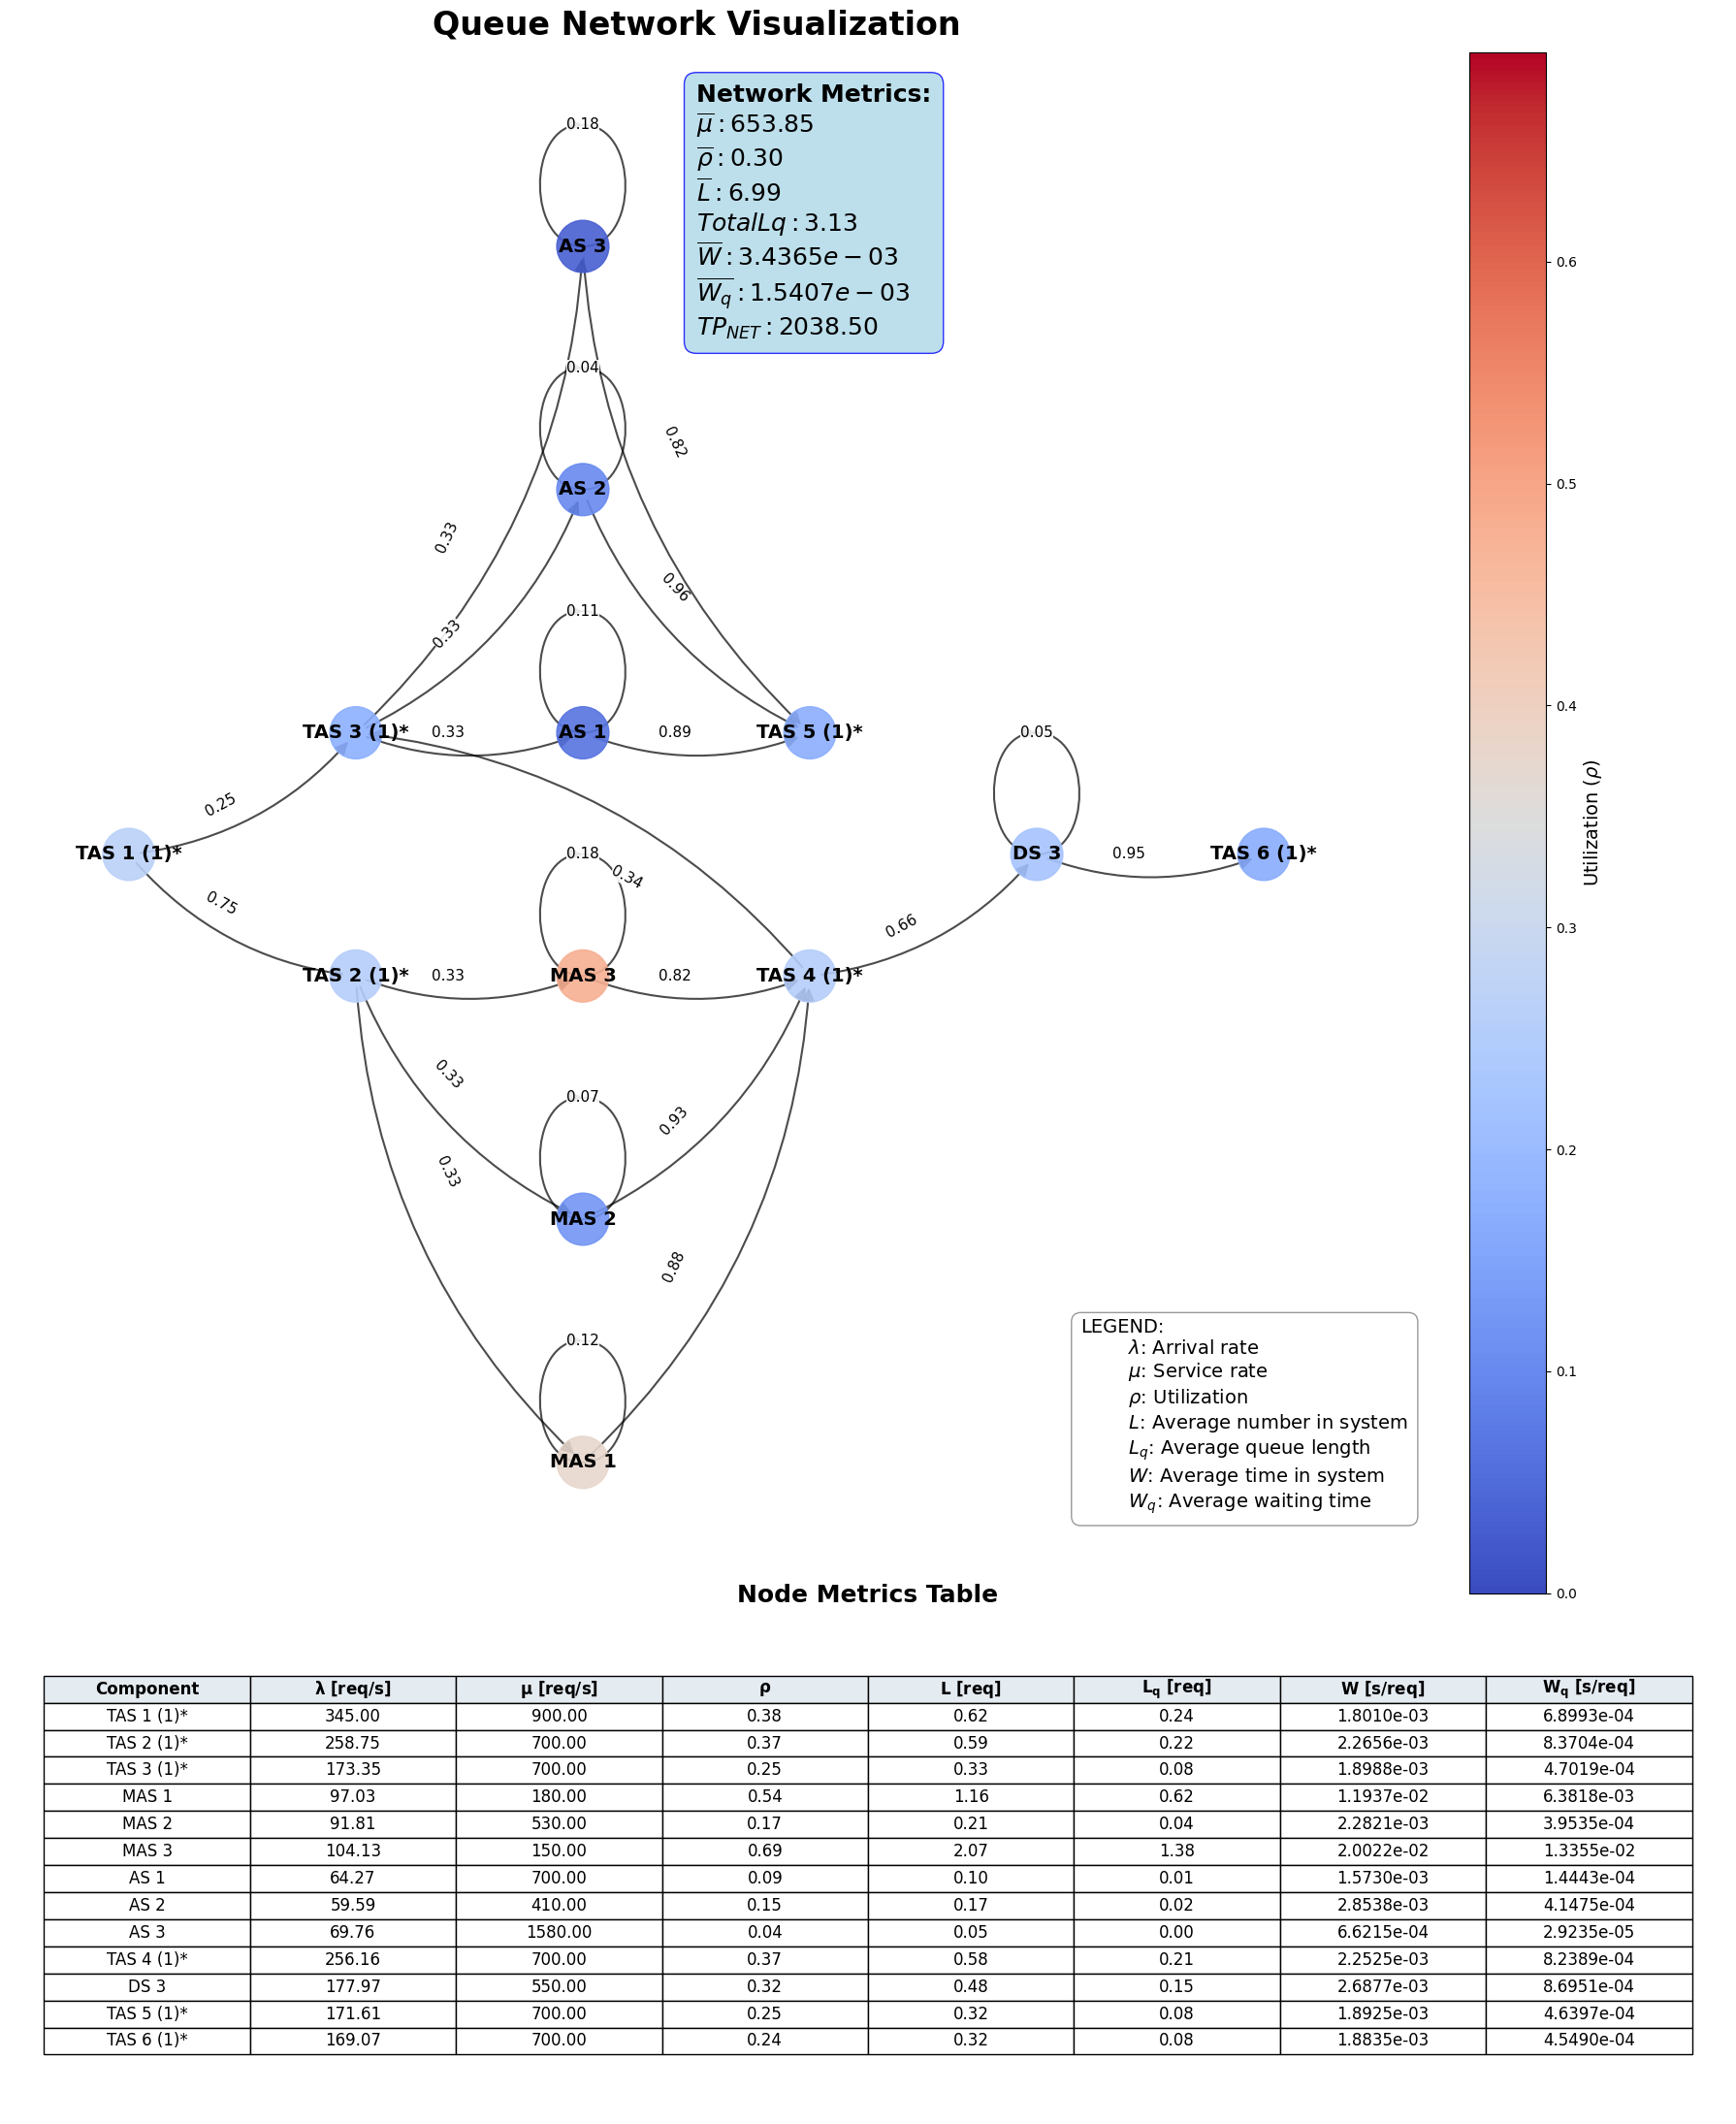

In [16]:
# plotting the queue network with metrics on each node
# data table column names
col_names = [
    "Component",
    r"$\mathbf{\lambda}$ [req/s]",
    r"$\mathbf{\mu}$ [req/s]",
    r"$\mathbf{\rho}$",
    r"$\mathbf{L}$ [req]",
    r"$\mathbf{L_q}$ [req]",
    r"$\mathbf{W}$ [s/req]",
    r"$\mathbf{W_q}$ [s/req]"
]

# extract routing matrix, last element of the analytical model tuple
P_routing = dflt_analytical_model[-1]

node_names = dflt_qn_cfg["name"].values.tolist()
print(f"Node names: {node_names}")  

# selecting images folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# Plot the queue network
plot_queue_network(P_routing,
                   dflt_analyt_net_metrics,
                   dflt_analyt_nd_metrics,
                   node_names,
                   col_names,
                   file_path,
                   "dflt_analytical_qn_diagram.png")

##### **Optimized Configuration**

In [17]:
# setting case study data folder
file_path = os.path.join(PATH, data_folder, config_folder, cs_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1


In [18]:
# Load configuration with mixed queue models
file_path = os.path.join(PATH, data_folder, config_folder, cs_folder)
opti_qn_cfg = load(file_path, "optimal_qn_model.csv")
print("Queue Network Configuration:")
# print(opti_qn_cfg)
opti_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1\optimal_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.20,0.40,0.40,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.40,0.20,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [19]:
print("Configuring optimal analytical model...")
opti_analytical_model = config_analytical_model(opti_qn_cfg, verbose=False)

Configuring optimal analytical model...


In [20]:
# Solve the network analytically
# first node metrics
opti_analyt_nd_metrics = solve_jackson_network(*opti_analytical_model)

In [21]:
# then network metrics
opti_analyt_net_metrics = calculate_net_metrics(opti_analyt_nd_metrics)
nodes = opti_analyt_nd_metrics["node"].tolist()
opti_analyt_net_metrics["nodes"] = len(nodes)

In [22]:
print("\n--- Analytical Jackson Network (Node Metrics) ---")
# print(opti_analyt_nd_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_analytical_node_metrics.csv", opti_analyt_nd_metrics)
opti_analyt_nd_metrics.info()
opti_analyt_nd_metrics.head()


--- Analytical Jackson Network (Node Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_analytical_node_metrics.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   node    13 non-null     int64  
 1   lambda  13 non-null     float64
 2   mu      13 non-null     int64  
 3   rho     13 non-null     float64
 4   L       13 non-null     float64
 5   Lq      13 non-null     float64
 6   W       13 non-null     float64
 7   Wq      13 non-null     float64
dtypes: float64(6), int64(2)
memory usage: 964.0 bytes


,node,lambda,mu,rho,L,Lq,W,Wq
0,1,345.000000,900,0.383333,0.621333,0.238016,0.001801,0.000690
1,2,258.750000,700,0.369643,0.586209,0.216577,0.002266,0.000837
2,3,174.225000,700,0.248893,0.331365,0.082473,0.001902,0.000473
3,4,58.806818,180,0.326705,0.485182,0.158481,0.008251,0.002695
4,5,111.290323,530,0.209982,0.265793,0.055811,0.002388,0.000501


In [23]:
print("\n--- Analytical Jackson Network (Network-wide Metrics) ---")
# print(opti_analyt_net_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_analytical_net_metrics.csv", opti_analyt_net_metrics)
opti_analyt_net_metrics.head()


--- Analytical Jackson Network (Network-wide Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_analytical_net_metrics.csv


,avg_mu,avg_rho,L_net,Lq_net,W_net,Wq_net,total_throughput,nodes
0,581.538462,0.284014,6.280818,2.594001,0.003107,0.001285,2026.435928,13


Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_analytical_qn_diagram.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_analytical_qn_diagram.png


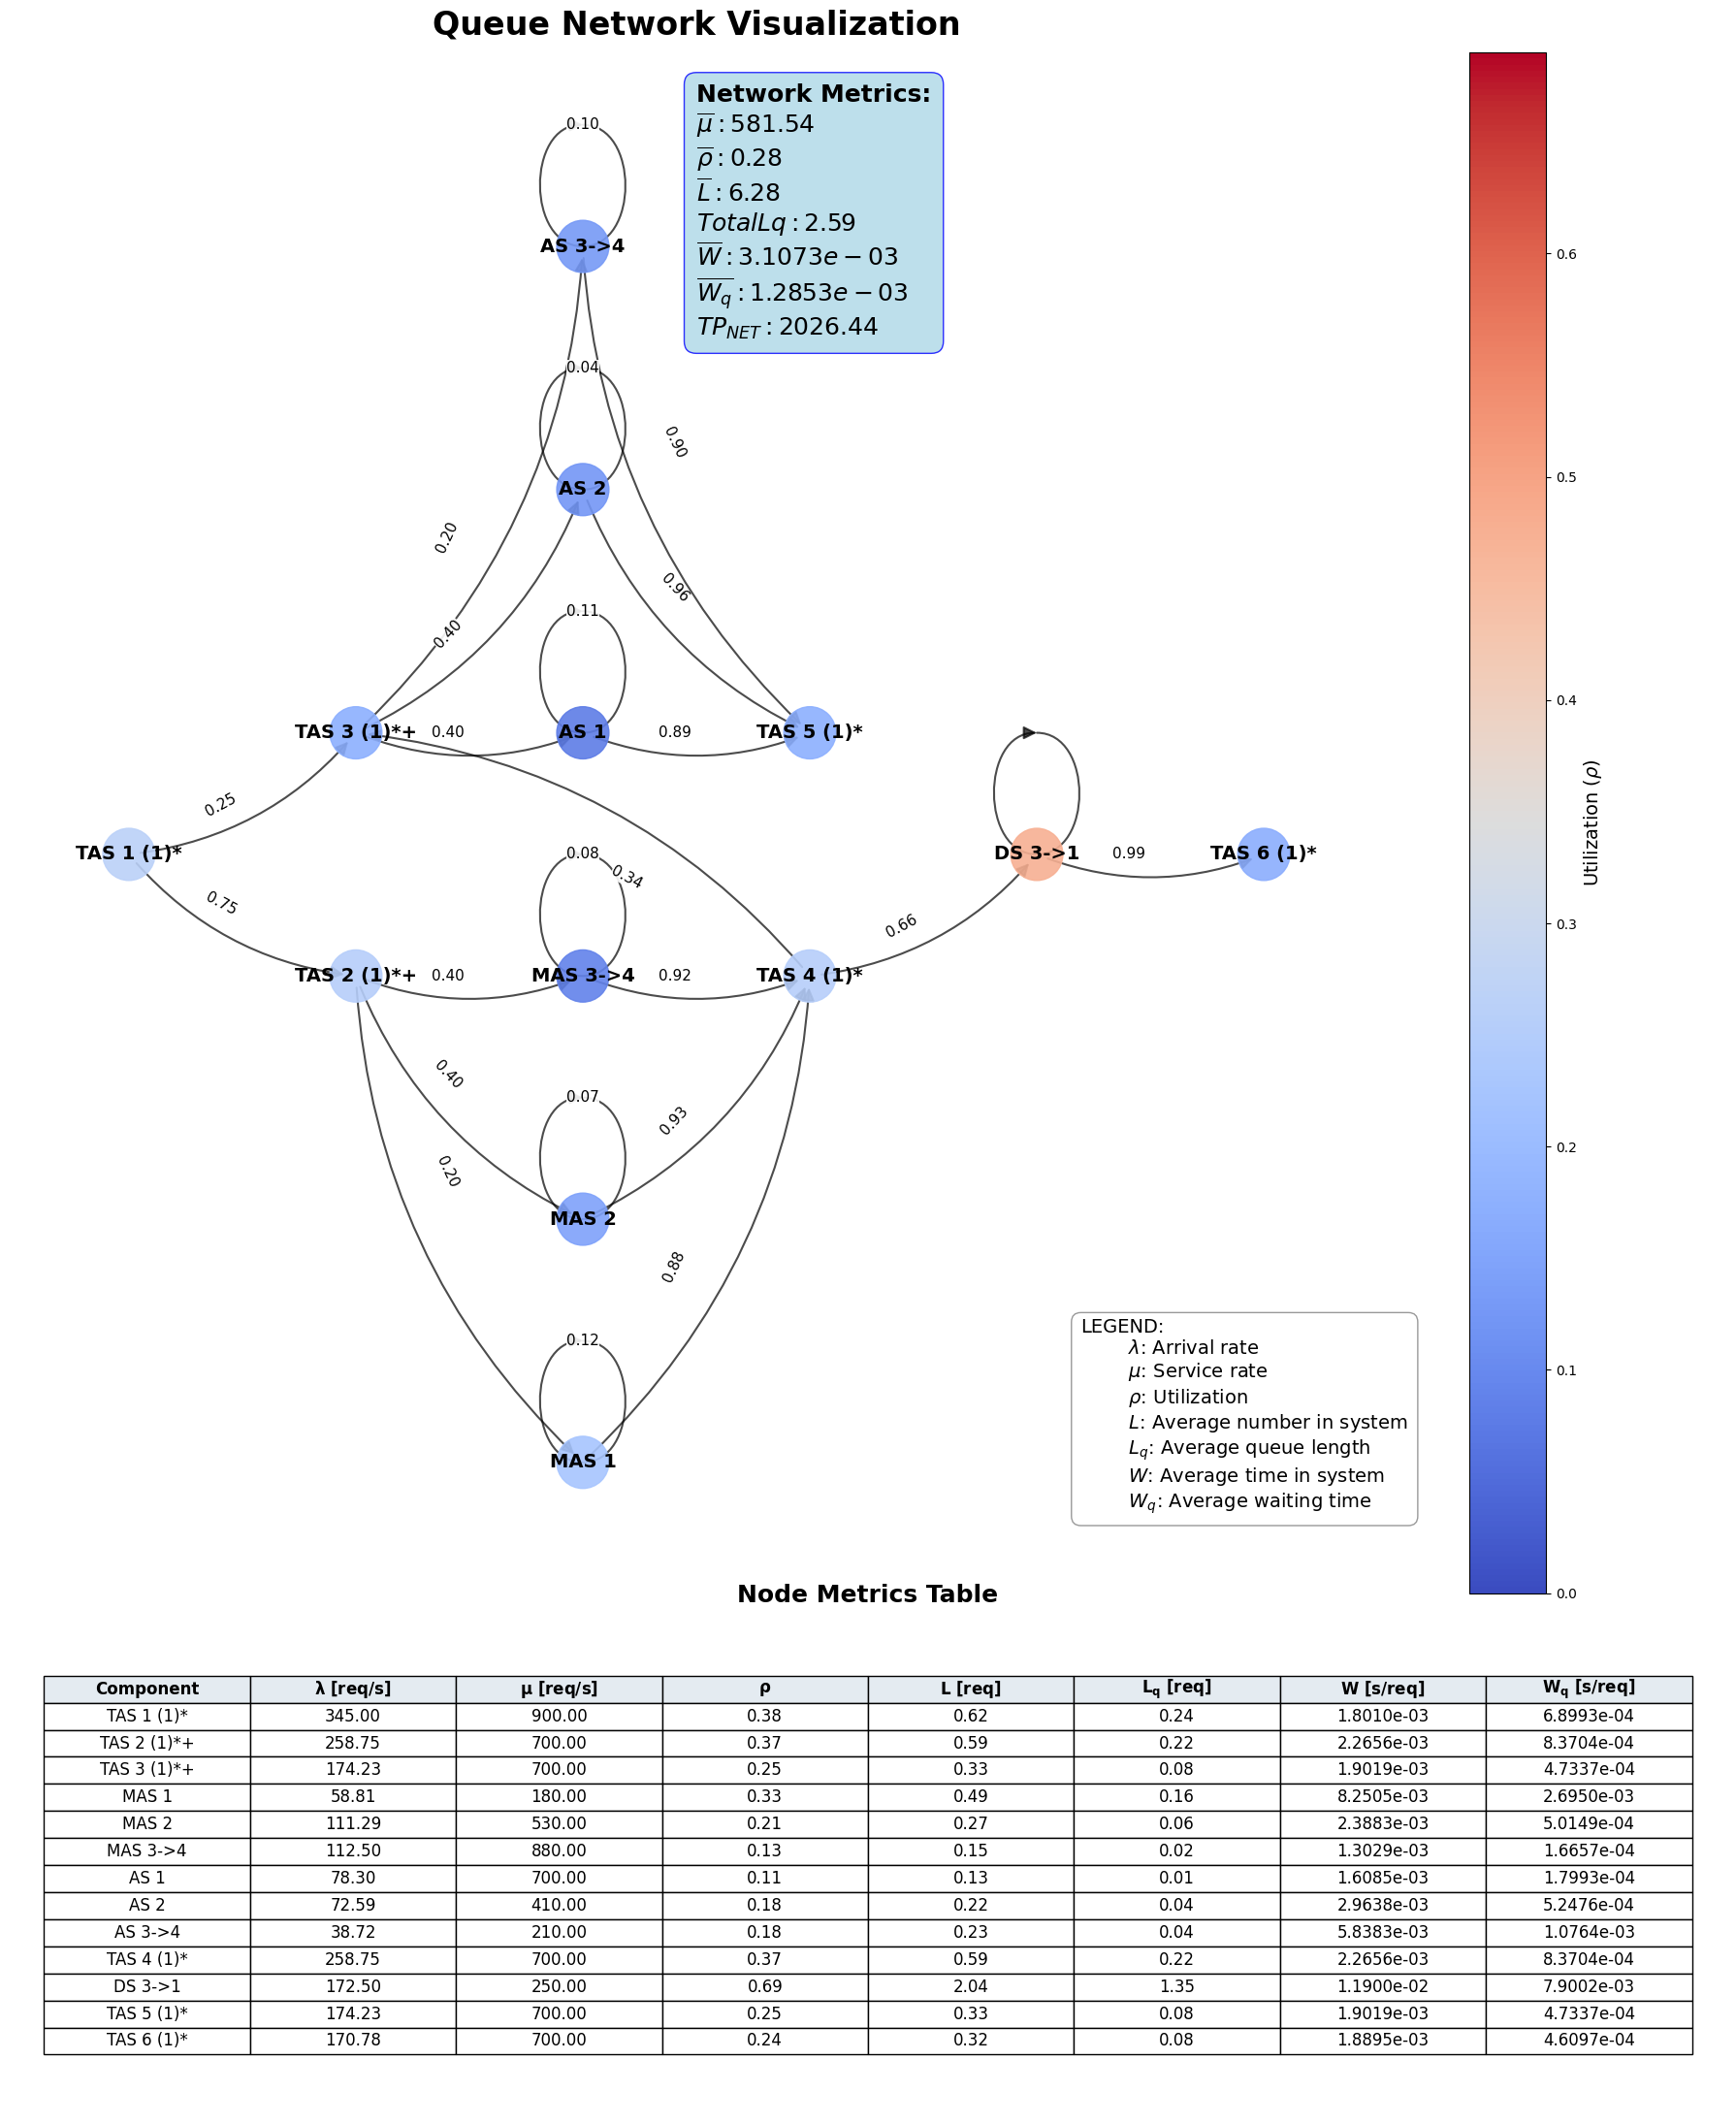

In [24]:
# plotting the queue network with metrics on each node
node_names = opti_qn_cfg["name"].values.tolist()
print(f"Node names: {node_names}")  

# selecting images folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# extract routing matrix, last element of the analytical model tuple
P_routing = opti_analytical_model[-1]

# Plot the queue network
plot_queue_network(P_routing,
                   opti_analyt_net_metrics,
                   opti_analyt_nd_metrics,
                   node_names,
                   col_names,
                   file_path,
                   "opti_analytical_qn_diagram.png")

## **Results**

### **Compare Results**

In [25]:
print("--- Calculating Network Metrics Differences---")
# comparing network metrics
diff_analyt_net_metrics = opti_analyt_net_metrics - dflt_analyt_net_metrics
delta_analyt_net_metrics = diff_analyt_net_metrics / dflt_analyt_net_metrics
delta_analyt_net_metrics

src_col_names = delta_analyt_net_metrics.columns.tolist()

tgt_col_names = [
    "delta_avg_mu",
    "delta_avg_rho",
    "delta_L_net",
    "delta_Lq_net",
    "delta_W_net",
    "delta_Wq_net",
    "delta_throughput",
    "delta_nodes",
]

rename_map = dict(zip(src_col_names, tgt_col_names))
# print(rename_map)

# rename comparison columns
delta_analyt_net_metrics.rename(columns=rename_map,
                               inplace=True)
delta_analyt_net_metrics.head()


--- Calculating Network Metrics Differences---


,delta_avg_mu,delta_avg_rho,delta_L_net,delta_Lq_net,delta_W_net,delta_Wq_net,delta_throughput,delta_nodes
0,-0.110588,-0.044622,-0.101109,-0.170939,-0.095803,-0.165781,-0.005919,0.0


In [26]:
# comparing node network metrics
print("--- Calculating Node/Component Metrics Differences---")
# extra data columns
extra_cols = [
    "node",
    "name",
    "type",
]


diff_analyt_nd_metrics = opti_analyt_nd_metrics - dflt_analyt_nd_metrics
delta_analyt_nd_metrics = diff_analyt_nd_metrics / dflt_analyt_nd_metrics.abs()
delta_analyt_nd_metrics

src_col_names = delta_analyt_nd_metrics.columns.tolist()

tgt_col_names = [
    "node",
    "delta_lambda",
    "delta_mu",
    "delta_rho",
    "delta_L",
    "delta_Lq",
    "delta_W",
    "delta_Wq",
]

rename_map = dict(zip(src_col_names, tgt_col_names))
# print(rename_map)

# rename comparison columns
delta_analyt_nd_metrics.rename(columns=rename_map,
                               inplace=True)

# adding node ID data
for col in extra_cols:
    if col in opti_qn_cfg.columns:
        delta_analyt_nd_metrics[col] = opti_qn_cfg[col].values

delta_analyt_nd_metrics.head()

--- Calculating Node/Component Metrics Differences---


,node,delta_lambda,delta_mu,delta_rho,delta_L,delta_Lq,delta_W,delta_Wq,name,type
0,1,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,TAS 1 (1)*,M/M/s/K
1,2,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,TAS 2 (1)*+,M/M/s/K
2,3,0.005075,0.0,0.005075,0.006757,0.011865,0.001673,0.006756,TAS 3 (1)*+,M/M/s/K
3,4,-0.393939,0.0,-0.393939,-0.580724,-0.743826,-0.308850,-0.577713,MAS 1,M/M/s/K
4,5,0.212121,0.0,0.212121,0.268500,0.537570,0.046513,0.268495,MAS 2,M/M/s/K


### **Saving Results**

In [27]:
# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path,
     "delta_analytical_node_metrics.csv",
     delta_analyt_nd_metrics)

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\delta_analytical_node_metrics.csv


In [28]:
# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                        results_folder,
                        cs_folder,
                        data_folder)
print(f"Data path: {file_path}")
save(file_path,
     "delta_analytical_net_metrics.csv",
     delta_analyt_net_metrics)

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\delta_analytical_net_metrics.csv


## **Analysis**

### **Graph Analysis**

In [29]:
# selecting images folder
print("--- Configuring folder path for plot parameters ---")
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

--- Configuring folder path for plot parameters ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img


In [30]:
print("--- Charting Overall Configuration Comparisons ---")
metrics = dflt_analyt_net_metrics.columns.tolist()
labels = [
    "$\\mathbf{\\mu}$ [req/s]",
    "$\\mathbf{\\rho}$ [%]",
    "$\\mathbf{L_{net}}$ [req]",
    "$\\mathbf{L_{q_{net}}}$ [req]",
    "$\\mathbf{W_{net}}$ [s/req]",
    "$\\mathbf{W_{q_{net}}}$ [s/req]",
    "$\\mathbf{Th_{net}}$ [req]",
    "$\\mathbf{n}$ [comp]",
]

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Overall Configuration Comparisons ---
avg_mu             : $\mathbf{\mu}$ [req/s]
avg_rho            : $\mathbf{\rho}$ [%]
L_net              : $\mathbf{L_{net}}$ [req]
Lq_net             : $\mathbf{L_{q_{net}}}$ [req]
W_net              : $\mathbf{W_{net}}$ [s/req]
Wq_net             : $\mathbf{W_{q_{net}}}$ [s/req]
total_throughput   : $\mathbf{Th_{net}}$ [req]
nodes              : $\mathbf{n}$ [comp]


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_analytical_metric_comparison.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_analytical_metric_comparison.png


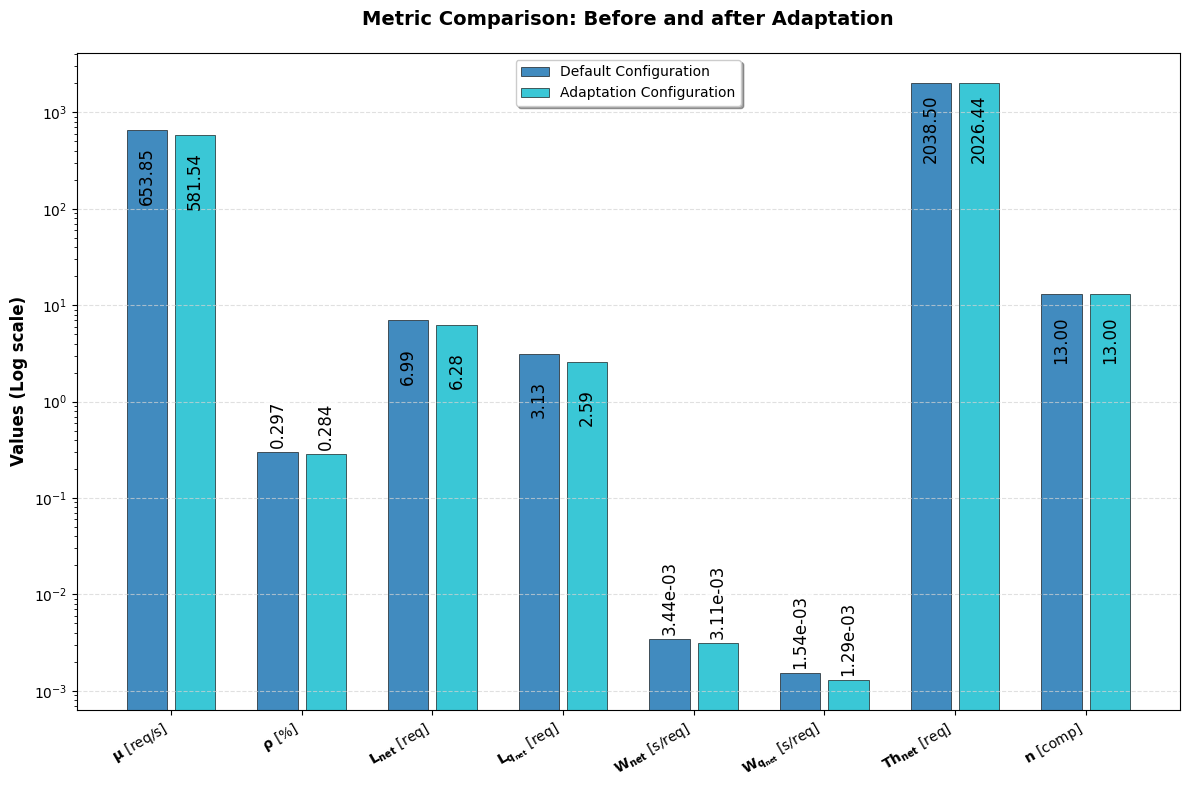

In [31]:
# Plot the metric comparison
plot_net_comparison([dflt_analyt_net_metrics, opti_analyt_net_metrics],
                    ["Default Configuration", "Adaptation Configuration"],
                    metrics,
                    labels,
                    "Metric Comparison: Before and after Adaptation",
                    file_path,
                    "net_analytical_metric_comparison.png")

In [32]:
print("--- Charting Overall Configuration differences ---")
metrics = delta_analyt_net_metrics.columns.tolist()
labels = [
    "$\\mathbf{\\overline{\\Delta \\mu}}$ [req/s]",
    "$\\mathbf{\\overline{\\Delta \\rho}}$ [n.a.]",
    "$\\mathbf{\\overline{\\Delta L}_{net}}$ [req]",
    "$\\mathbf{\\overline{\\Delta L}_{q_{net}}}$ [req]",
    "$\\mathbf{\\overline{\\Delta W}_{net}}$ [s/req]",
    "$\\mathbf{\\overline{\\Delta W}_{q_{net}}}$ [s/req]",
    "$\\mathbf{\\overline{\\Delta Th}_{net}}$ [req]",
    "$\\mathbf{\\overline{\\Delta n}}$ [comp]",
]

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Overall Configuration differences ---
delta_avg_mu       : $\mathbf{\overline{\Delta \mu}}$ [req/s]
delta_avg_rho      : $\mathbf{\overline{\Delta \rho}}$ [n.a.]
delta_L_net        : $\mathbf{\overline{\Delta L}_{net}}$ [req]
delta_Lq_net       : $\mathbf{\overline{\Delta L}_{q_{net}}}$ [req]
delta_W_net        : $\mathbf{\overline{\Delta W}_{net}}$ [s/req]
delta_Wq_net       : $\mathbf{\overline{\Delta W}_{q_{net}}}$ [s/req]
delta_throughput   : $\mathbf{\overline{\Delta Th}_{net}}$ [req]
delta_nodes        : $\mathbf{\overline{\Delta n}}$ [comp]


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_analytical_metric_differences.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_analytical_metric_differences.png


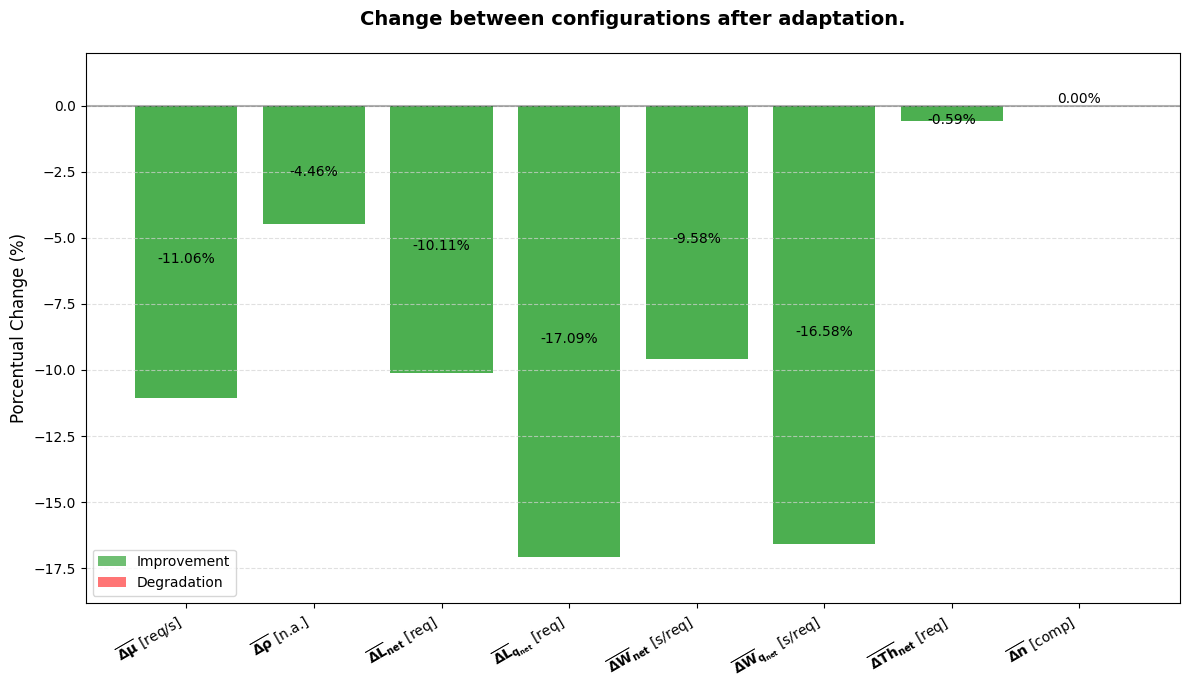

In [33]:
# Plot the metric differences
plot_net_difference(delta_analyt_net_metrics,
                    metrics,
                    labels,
                    "Change between configurations after adaptation.",
                    file_path,
                    "net_analytical_metric_differences.png")

In [34]:
print("--- Charting Component Queue-Network Comparative Heatmap ---")
# Define metrics for the heatmap X-axis
metrics = delta_analyt_nd_metrics.select_dtypes(include="number")
metrics = metrics.columns.tolist()
if "node" in metrics:
    metrics.remove("node")

# define the labels for the heatmap X-axis alias
labels = [
    "$\\mathbf{\\Delta\\lambda}$ [req/s]",
    "$\\mathbf{\\Delta \\mu}$ [req/s]",
    "$\\mathbf{\\Delta \\rho}$ [n.a.]",
    "$\\mathbf{\\Delta L_{net}}$ [req]",
    "$\\mathbf{\\Delta L_{q_{net}}}$ [req]",
    "$\\mathbf{\\Delta W_{net}}$ [s/req]",
    "$\\mathbf{\\Delta W_{q_{net}}}$ [s/req]",
]

# define the node names for the heatmap Y-axis
node_names = delta_analyt_nd_metrics["name"].values.tolist()
print(f"Node names: {node_names}")

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Component Queue-Network Comparative Heatmap ---
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
delta_lambda       : $\mathbf{\Delta\lambda}$ [req/s]
delta_mu           : $\mathbf{\Delta \mu}$ [req/s]
delta_rho          : $\mathbf{\Delta \rho}$ [n.a.]
delta_L            : $\mathbf{\Delta L_{net}}$ [req]
delta_Lq           : $\mathbf{\Delta L_{q_{net}}}$ [req]
delta_W            : $\mathbf{\Delta W_{net}}$ [s/req]
delta_Wq           : $\mathbf{\Delta W_{q_{net}}}$ [s/req]


In [35]:
print("--- Preparing data for heatmaps ---")
dflt_analyt_nd_metrics["name"] = node_names
opti_analyt_nd_metrics["name"] = node_names

--- Preparing data for heatmaps ---


In [36]:
print("--- Charting Component Queue-Network Configuration Heatmap ---")
metrics = dflt_analyt_nd_metrics.select_dtypes(include="number")
metrics = metrics.columns.tolist()
if "node" in metrics:
    metrics.remove("node")

labels = [
    # "$\\mathbf{n}$ [comp]",
    "$\\mathbf{\\lambda}$ [req/s]",
    "$\\mathbf{\\mu}$ [req/s]",
    "$\\mathbf{\\rho}$ [%]",
    "$\\mathbf{L}$ [req]",
    "$\\mathbf{L_{q}}$ [req]",
    "$\\mathbf{W}$ [s/req]",
    "$\\mathbf{W_{q}}$ [s/req]",
]

# define the node names for the heatmap Y-axis
node_names = delta_analyt_nd_metrics["name"].values.tolist()
print(f"Node names: {node_names}")

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Component Queue-Network Configuration Heatmap ---
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
lambda             : $\mathbf{\lambda}$ [req/s]
mu                 : $\mathbf{\mu}$ [req/s]
rho                : $\mathbf{\rho}$ [%]
L                  : $\mathbf{L}$ [req]
Lq                 : $\mathbf{L_{q}}$ [req]
W                  : $\mathbf{W}$ [s/req]
Wq                 : $\mathbf{W_{q}}$ [s/req]


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_analytical_metric_heatmap.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_analytical_metric_heatmap.png


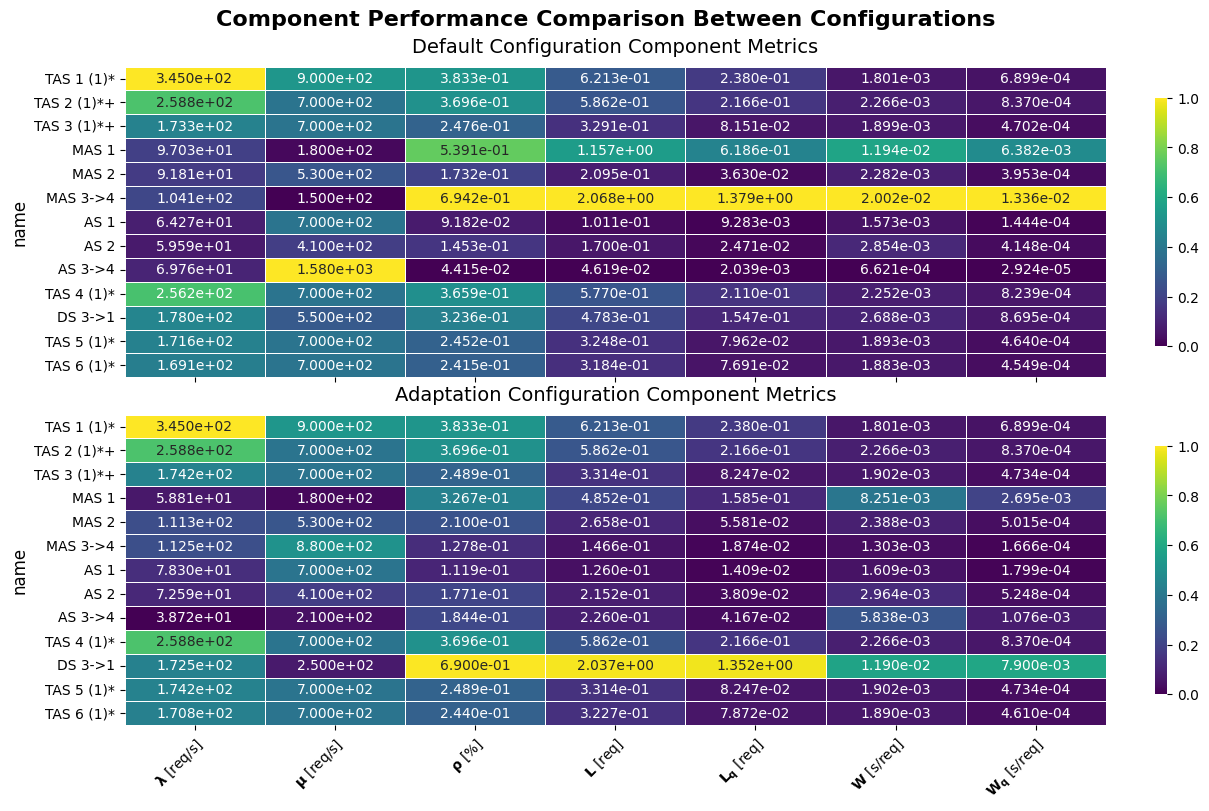

In [37]:
plot_nodes_heatmap([dflt_analyt_nd_metrics, opti_analyt_nd_metrics],
                   ["Default Configuration", "Adaptation Configuration"],
                   node_names,
                   metrics,
                   labels,
                   "Component Performance Comparison Between Configurations",
                   "name",
                   file_path,
                   "nodes_analytical_metric_heatmap.png")

In [38]:
print("--- Charting Component Queue-Network Differential Heatmap ---")
# Define metrics for the heatmap X-axis
metrics = delta_analyt_nd_metrics.select_dtypes(include="number")
metrics = metrics.columns.tolist()
if "node" in metrics:
    metrics.remove("node")

# define the labels for the heatmap X-axis alias
labels = [
    "$\\mathbf{\\Delta\\lambda}$ [%]",
    "$\\mathbf{\\Delta \\mu}$ [%]",
    "$\\mathbf{\\Delta \\rho}$ [%]",
    "$\\mathbf{\\Delta L_{net}}$ [%]",
    "$\\mathbf{\\Delta L_{q_{net}}}$ [%]",
    "$\\mathbf{\\Delta W_{net}}$ [%]",
    "$\\mathbf{\\Delta W_{q_{net}}}$ [%]",
]

# define the node names for the heatmap Y-axis
node_names = delta_analyt_nd_metrics["name"].values.tolist()
print(f"Node names: {node_names}")

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Component Queue-Network Differential Heatmap ---
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
delta_lambda       : $\mathbf{\Delta\lambda}$ [%]
delta_mu           : $\mathbf{\Delta \mu}$ [%]
delta_rho          : $\mathbf{\Delta \rho}$ [%]
delta_L            : $\mathbf{\Delta L_{net}}$ [%]
delta_Lq           : $\mathbf{\Delta L_{q_{net}}}$ [%]
delta_W            : $\mathbf{\Delta W_{net}}$ [%]
delta_Wq           : $\mathbf{\Delta W_{q_{net}}}$ [%]


Found 13 nodes: ['TAS 1 (1)*' 'TAS 2 (1)*+' 'TAS 3 (1)*+' 'MAS 1' 'MAS 2' 'MAS 3->4'
 'AS 1' 'AS 2' 'AS 3->4' 'TAS 4 (1)*' 'DS 3->1' 'TAS 5 (1)*' 'TAS 6 (1)*']
Heatmap data shape: (13, 7)
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_analytical_metric_diffmap.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_analytical_metric_diffmap.png


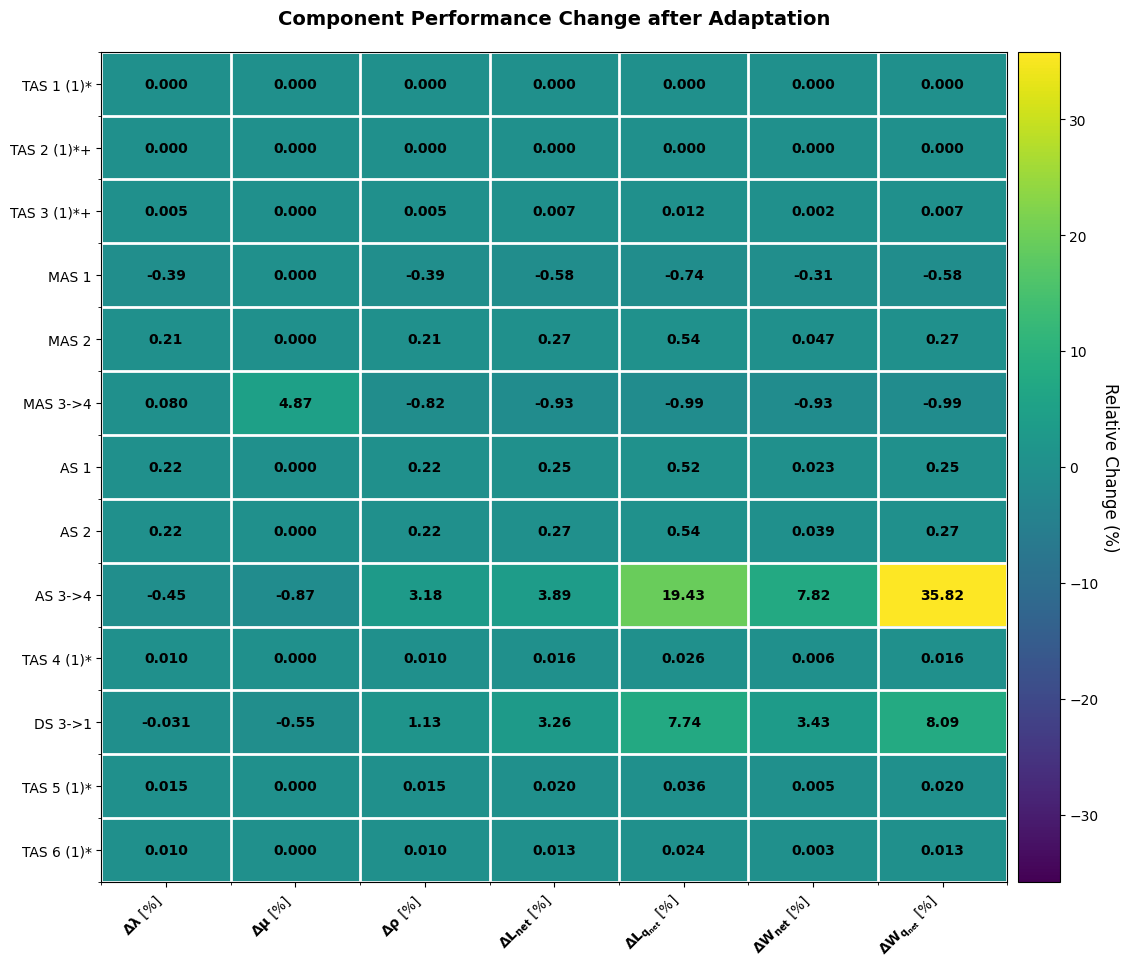

In [39]:
plot_nodes_diffmap(delta_analyt_nd_metrics,
                   node_names,
                   metrics,
                   labels,
                   "Component Performance Change after Adaptation",
                   "name",
                   file_path,
                   "nodes_analytical_metric_diffmap.png")

## **Conclusion**

## **Future Work**

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **HASTA AKI!!!**